<a href="https://colab.research.google.com/github/arjunraj13/image_colourization/blob/main/image_colourization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:04<00:00, 37.4MB/s]


In [ ]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(1,64,3,1,1),
            nn.ReLU(),

            nn.Conv2d(64,128,3,1,1),
            nn.ReLU(),

            nn.Conv2d(128,64,3,1,1),
            nn.ReLU(),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(8192,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
l1_loss = nn.L1Loss()

opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [ ]:
epochs = 60

for epoch in range(epochs):

    for real,_ in loader:

        real = real.to(device)

        gray = real.mean(dim=1, keepdim=True)

        batch = real.size(0)

        # Generator output
        fake = G(gray)

        # Train Discriminator
        D_real = D(real)
        D_fake = D(fake.detach())

        loss_real = criterion(D_real, torch.ones(batch,1).to(device))
        loss_fake = criterion(D_fake, torch.zeros(batch,1).to(device))

        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        output = D(fake)

        adv_loss = criterion(output, torch.ones(batch,1).to(device))
        recon_loss = l1_loss(fake, real)

        loss_G = adv_loss + 100*recon_loss

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print("Epoch:", epoch, "D Loss:", loss_D.item(), "G Loss:", loss_G.item())

Epoch: 0 D Loss: 1.0035271644592285 G Loss: 5.765738487243652
Epoch: 1 D Loss: 1.2565385103225708 G Loss: 5.712822437286377
Epoch: 2 D Loss: 1.732423186302185 G Loss: 7.107100963592529
Epoch: 3 D Loss: 0.7926129698753357 G Loss: 5.595941543579102
Epoch: 4 D Loss: 1.5896308422088623 G Loss: 6.9709978103637695
Epoch: 5 D Loss: 0.8527951240539551 G Loss: 6.039212226867676
Epoch: 6 D Loss: 1.479628562927246 G Loss: 7.6947340965271
Epoch: 7 D Loss: 0.8588414788246155 G Loss: 6.954866409301758
Epoch: 8 D Loss: 1.083817720413208 G Loss: 5.706494331359863
Epoch: 9 D Loss: 0.747523307800293 G Loss: 7.687285900115967
Epoch: 10 D Loss: 0.8753670454025269 G Loss: 6.513873100280762
Epoch: 11 D Loss: 0.8025038242340088 G Loss: 6.430822849273682
Epoch: 12 D Loss: 1.0967538356781006 G Loss: 6.836312294006348
Epoch: 13 D Loss: 1.2376258373260498 G Loss: 5.609336853027344
Epoch: 14 D Loss: 0.633280336856842 G Loss: 6.675729274749756
Epoch: 15 D Loss: 0.8850806355476379 G Loss: 6.145965099334717
Epoch: 1

# Test

In [ ]:
real,_ = next(iter(loader))

real = real.to(device)

gray = real.mean(dim=1,keepdim=True)

fake = G(gray).cpu().detach()

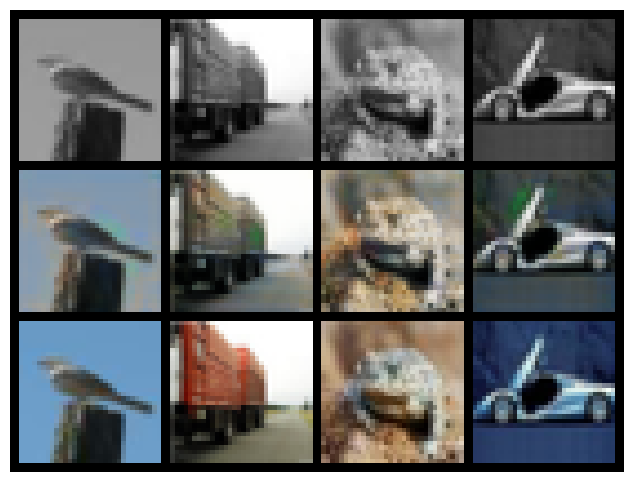

In [ ]:
import torchvision

def show_images(gray, fake, real):

    gray = gray.repeat(1,3,1,1)

    images = torch.cat([gray[:4], fake[:4], real[:4]],0)

    grid = torchvision.utils.make_grid(images, nrow=4)

    plt.figure(figsize=(8,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
show_images(gray.cpu(), fake, real.cpu())